In [7]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 처음 실행하는 경우 아래 두 줄의 주석을 풀어 설치하세요.
%pip install missingno plotly -q
!pip install --upgrade nbformat
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import plotly.express as px
import plotly.io as pio

warnings.filterwarnings("ignore")
np.random.seed(42)

# 한글 폰트 (운영체제별 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# Plotly는 환경에 따라 기본 렌더러가 다릅니다.
# 노트북에서 인터랙티브로 보이도록 명시적으로 지정합니다.
try:
    pio.renderers.default = "notebook"
except Exception:
    pass

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("pandas    :", pd.__version__)
print("seaborn   :", sns.__version__)
print("missingno :", msno.__version__ if hasattr(msno, "__version__") else "(installed)")

Note: you may need to restart the kernel to use updated packages.
준비 완료! 라이브러리 버전을 확인합니다.
pandas    : 3.0.3
seaborn   : 0.13.2
missingno : 0.5.2


In [8]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 정제 전(raw)과 정제 후(clean) 두 버전
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객
n_customers = 500
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})
# 일부러 심은 오염
customers.loc[5, "age"] = 999
customers.loc[10, "age"] = -3
customers.loc[[20, 21, 22, 23], "gender"] = np.nan
customers.loc[30, "region"] = " 서울 "

# 2) 상품
categories = ["패션", "뷰티", "식품", "가전", "도서"]
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, 41)],
    "category": np.random.choice(categories, 40),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], 40),
})

# 3) 주문 — 정제 전 버전
n_orders = 3000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders_raw = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity.astype(float),
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05]),
})

# 의도적 오염: amount의 일부는 결측(특히 web 채널에서 더 자주 결측 — MAR 패턴)
web_mask = orders_raw["channel"] == "web"
web_idx = orders_raw[web_mask].sample(150, random_state=1).index
other_idx = orders_raw[~web_mask].sample(40, random_state=1).index
orders_raw.loc[web_idx, "amount"] = np.nan
orders_raw.loc[other_idx, "amount"] = np.nan

# quantity 이상치
orders_raw.loc[7, "quantity"] = 100
orders_raw.loc[123, "quantity"] = 80

# amount 이상치(VIP 한 명의 대량 구매)
orders_raw.loc[200, "amount"] = 5_000_000

# 중복 행
orders_raw = pd.concat([orders_raw, orders_raw.iloc[[0, 1, 2]]], ignore_index=True)

# 날짜 — 일부 포맷 혼재
base_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 120, len(orders_raw)), unit="D"
)
orders_raw["order_date"] = base_dates

# 4) 정제 후 버전 — D+003~D+007에서 배운 기법을 적용했다고 가정
orders_clean = orders_raw.copy()
# (a) 중복 제거
orders_clean = orders_clean.drop_duplicates(subset="order_id").reset_index(drop=True)
# (b) channel 표기 통일
orders_clean["channel"] = orders_clean["channel"].str.strip().str.lower()
# (c) quantity 이상치를 IQR 기준 상한으로 클리핑
q1, q3 = orders_clean["quantity"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
orders_clean.loc[orders_clean["quantity"] > upper, "quantity"] = upper
# (d) amount 결측은 'product_id 평균 단가 × 수량'으로 대체
mean_unit_price = (orders_clean.dropna(subset=["amount"])
                   .assign(unit=lambda d: d["amount"] / d["quantity"])
                   .groupby("product_id")["unit"].mean())
need_fill = orders_clean["amount"].isna()
orders_clean.loc[need_fill, "amount"] = (
    orders_clean.loc[need_fill, "product_id"].map(mean_unit_price)
    * orders_clean.loc[need_fill, "quantity"]
)
# (e) amount 극단 이상치도 99% 분위수로 클리핑
cap = orders_clean["amount"].quantile(0.99)
orders_clean.loc[orders_clean["amount"] > cap, "amount"] = cap

print("정제 전 :", orders_raw.shape, "결측 amount:", orders_raw["amount"].isna().sum())
print("정제 후 :", orders_clean.shape, "결측 amount:", orders_clean["amount"].isna().sum())

정제 전 : (3003, 7) 결측 amount: 189
정제 후 : (3000, 7) 결측 amount: 0


In [9]:
# 두 데이터의 머리 부분을 한 번씩 보고, 컬럼이 같은지 확인합니다.
print("[orders_raw]")
display(orders_raw.head(3))
print("[orders_clean]")
display(orders_clean.head(3))

[orders_raw]


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0149,P018,1.0,49900.0,app,2025-03-08
1,O00002,C0126,P002,1.0,49900.0,web,2025-03-07
2,O00003,C0392,P008,2.0,99800.0,web,2025-02-21


[orders_clean]


,order_id,customer_id,product_id,quantity,amount,channel,order_date
0,O00001,C0149,P018,1.0,49900.0,app,2025-03-08
1,O00002,C0126,P002,1.0,49900.0,web,2025-03-07
2,O00003,C0392,P008,2.0,99800.0,web,2025-02-21


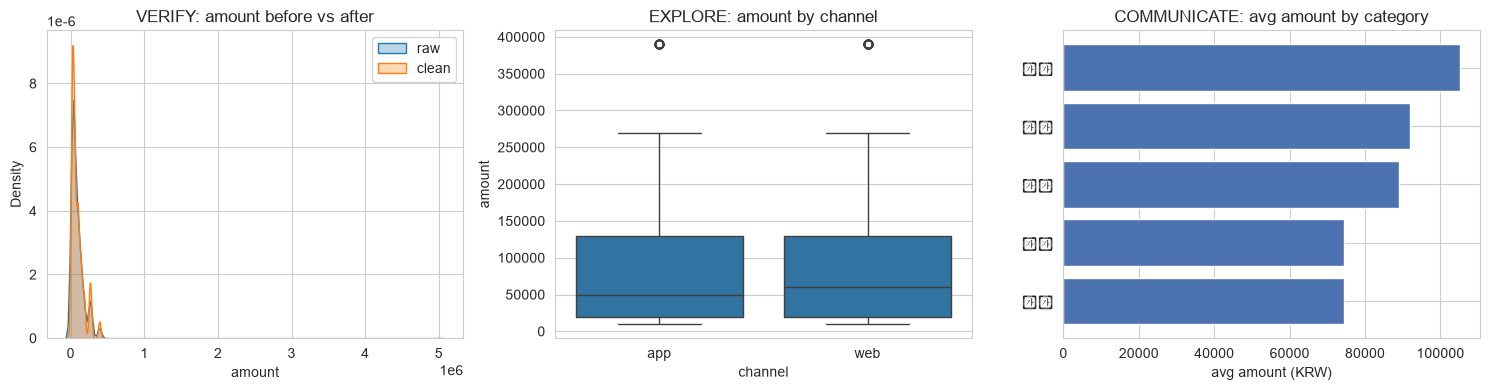

<Axes: >

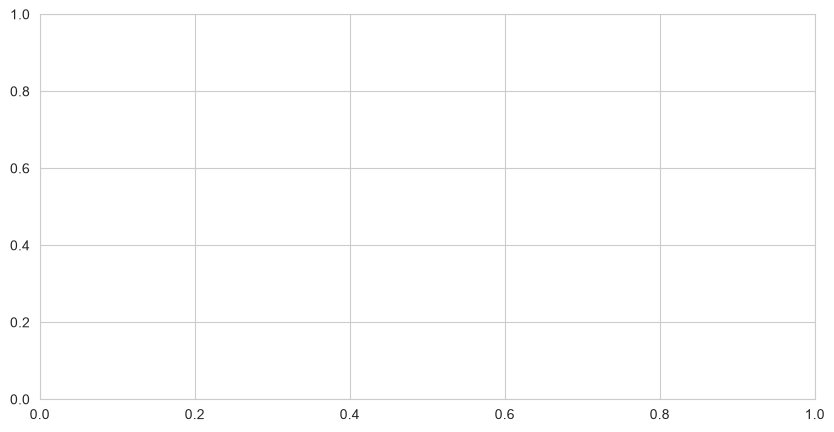

In [10]:
# 같은 데이터, 다른 목적 — 세 가지 그림으로 보여주기 (맛보기)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (검증) 정제 전·후 amount 분포 겹쳐 그리기
sns.kdeplot(orders_raw["amount"].dropna(), ax=axes[0], label="raw", fill=True, alpha=0.3)
sns.kdeplot(orders_clean["amount"], ax=axes[0], label="clean", fill=True, alpha=0.3)
axes[0].set_title("VERIFY: amount before vs after")
axes[0].legend()

# (탐색) channel별 amount 박스 — 어떤 채널이 큰 금액?
sns.boxplot(data=orders_clean, x="channel", y="amount", ax=axes[1])
axes[1].set_title("EXPLORE: amount by channel")

# (전달) 카테고리별 평균 매출 — 한 메시지
cat_sales = (orders_clean.merge(products, on="product_id")
             .groupby("category")["amount"].mean().sort_values())
axes[2].barh(cat_sales.index, cat_sales.values, color="#4C72B0")
axes[2].set_title("COMMUNICATE: avg amount by category")
axes[2].set_xlabel("avg amount (KRW)")

plt.tight_layout(); plt.show()


sns.kdeplot()

In [11]:
# 스스로 해보자! (1) — 머릿속으로 답한 뒤 아래 한 줄에 적어보세요.
# 1) 검증 (검증/탐색/전달)
# 2) 탐색
# 3) 전달

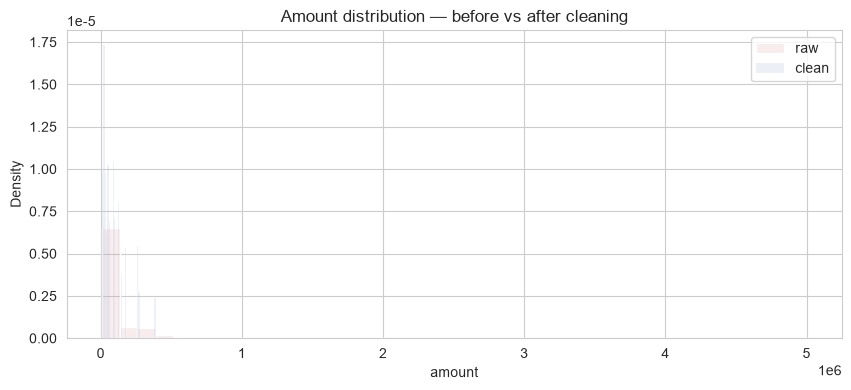

In [ ]:
# 1) 히스토그램 겹쳐 그리기 — amount의 정제 전·후
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(orders_raw["amount"].dropna(), bins=40, alpha=0.5,
             label="raw", color="#C44E52", ax=ax, stat="density")
sns.histplot(orders_clean["amount"], bins=40, alpha=0.5,
             label="clean", color="#4C72B0", ax=ax, stat="density")
ax.set_title("Amount distribution — before vs after cleaning")
ax.set_xlabel("amount"); ax.legend()
plt.show()

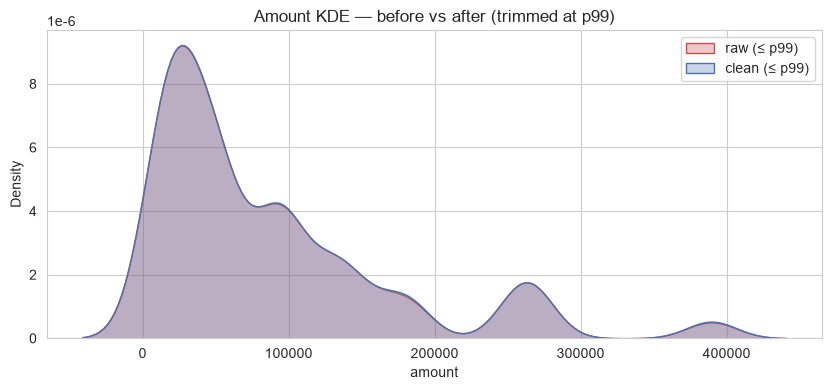

In [13]:
# 2) KDE 겹쳐 그리기 — 극단치 클리핑한 좁은 범위로
upper = orders_clean["amount"].quantile(0.99)
raw_trim = orders_raw["amount"].dropna()
raw_trim = raw_trim[raw_trim <= upper]
clean_trim = orders_clean["amount"][orders_clean["amount"] <= upper]

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(raw_trim, label="raw (≤ p99)", color="#C44E52", fill=True, alpha=0.3, ax=ax)
sns.kdeplot(clean_trim, label="clean (≤ p99)", color="#4C72B0", fill=True, alpha=0.3, ax=ax)
ax.set_title("Amount KDE — before vs after (trimmed at p99)")
ax.set_xlabel("amount"); ax.legend()
plt.show()

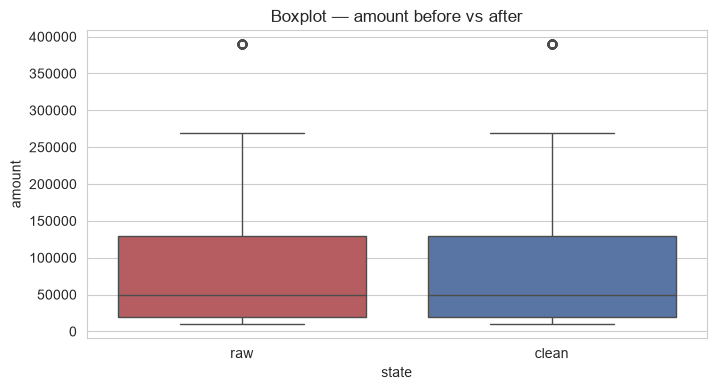

In [14]:
# 3) Boxplot side-by-side — state 컬럼으로 두 상태 합치기
raw_amt = pd.DataFrame({"amount": orders_raw["amount"].dropna(), "state": "raw"})
cln_amt = pd.DataFrame({"amount": orders_clean["amount"], "state": "clean"})
long_amt = pd.concat([raw_amt, cln_amt], ignore_index=True)
long_amt = long_amt[long_amt["amount"] <= upper]   # 시각화를 위해 p99로 클립

plt.figure(figsize=(8, 4))
sns.boxplot(data=long_amt, x="state", y="amount",
            order=["raw", "clean"], palette=["#C44E52", "#4C72B0"])
plt.title("Boxplot — amount before vs after")
plt.show()

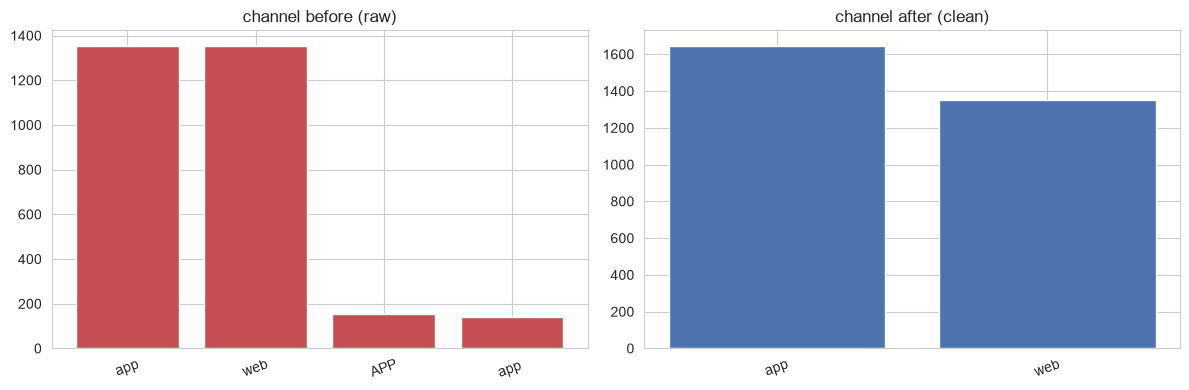

In [15]:
# 4) 범주 정제 검증 — 막대 그래프
raw_ch = orders_raw["channel"].value_counts()
cln_ch = orders_clean["channel"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(raw_ch.index, raw_ch.values, color="#C44E52")
axes[0].set_title("channel before (raw)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(cln_ch.index, cln_ch.values, color="#4C72B0")
axes[1].set_title("channel after (clean)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

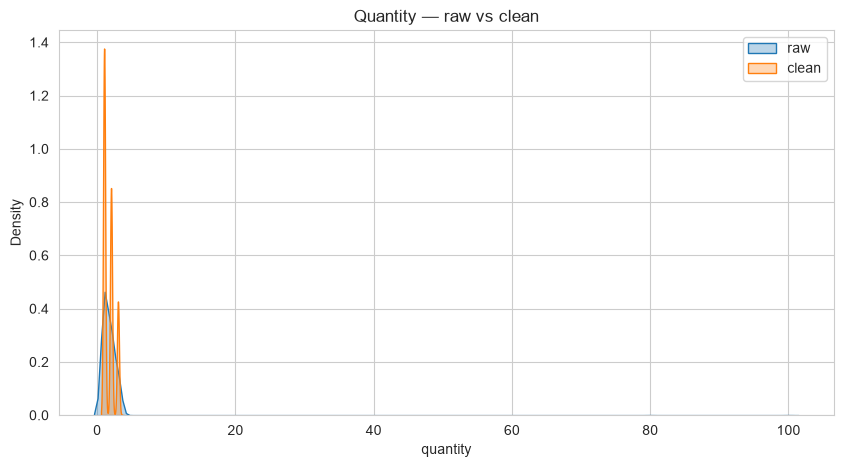

In [16]:
# 스스로 해보자! (3)
# 1) quantity KDE 겹쳐 그리기
sns.kdeplot(orders_raw["quantity"], label="raw", fill=True, alpha=0.3)
sns.kdeplot(orders_clean["quantity"], label="clean", fill=True, alpha=0.3)
plt.legend(); plt.title("Quantity — raw vs clean"); plt.show()